# Preliminaries

In [4]:
import torch
import torch.optim as optim 
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
import torch.nn.functional as F 
import numpy as np
import matplotlib.pyplot as plt 

In [5]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [26]:
# Get training data
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)
train_loader = DataLoader(dataset=training_data, batch_size=128,shuffle=True)

# Dimension of 28x28 

# The network

In [27]:
# Define model, encoder decoder seperately
class Encoder(nn.Module):
    # allows for hidden layer etc. experimentation
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()
        self.f_mu = nn.Linear(hidden_dim,latent_dim)
        self.f_logvar = nn.Linear(hidden_dim,latent_dim)

        # We use a stack here to make iterating on the model sligthly easier
        self.encoder_stack = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
        )

    def forward(self,x):
        enc_stack = self.encoder_stack(x)
        mu = self.f_mu(enc_stack)
        f_logvar = self.f_logvar(enc_stack)

        return mu, f_logvar

class Decoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Decoder, self).__init__()
        self.decoder_stack= nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )        

    def forward(self,x): 
        output = self.decoder_stack(x)
        return output


class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(input_dim, hidden_dim, latent_dim)

    # needed to make the gradients flow
    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5*logvar) # standard deviation
        eps = torch.randn_like(std) # random noise
        return mu+eps*std   # sample

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z= self.reparameterise(mu,logvar)
        reconstructed = self.decoder(z)
        return reconstructed, mu, logvar
    

# Training the model

In [28]:
def loss_function(recon_x, x, mu, logvar):
    # reconstruction loss (binary cross entropy)
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')

    # KL divergence loss
    kl_loss = -0.5*torch.sum(1+logvar-mu.pow(2)-logvar.exp())
    return recon_loss + kl_loss

Basically a very iterative approach, we started with 10 epohcs, and now we have 100 epochs. We also added a scheduler (ReduceLROnPlateau) as during training iterations the LR seemed to exhibit some plateauing so we introduce a scheduler (ReduceLROnPlateau) to try to improve model performance further. Additional improvements can be made to the model architechture, which we work more with afterwards.

Epoch 1, Loss: 164.7419
Epoch 11, Loss: 105.8268
Epoch 21, Loss: 103.8531
Epoch 31, Loss: 102.8992
Epoch 41, Loss: 102.2807
Epoch 51, Loss: 101.8310
Epoch 61, Loss: 101.4990
Epoch 71, Loss: 101.1950
Epoch 81, Loss: 101.0028
Epoch 91, Loss: 100.7844


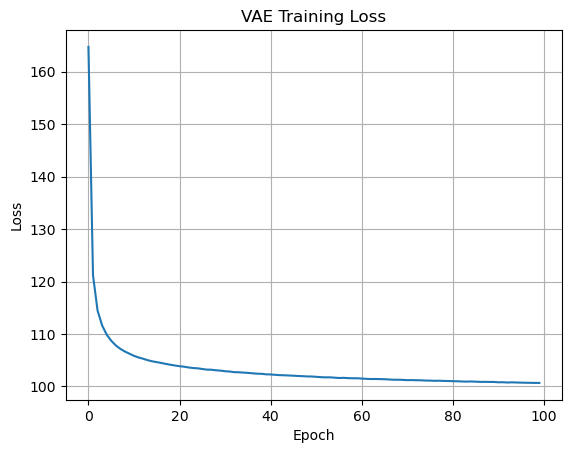

In [51]:
epochs = 100
learning_rate = 1e-3

model = VAE().to(device)
optimizer = torch.optim.AdamW(model.parameters(),lr=learning_rate)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    mode='min',
    factor=0.5,
    patience=5,
)


train_losses = []

model.train()

for epoch in range(epochs):
    total_loss = 0
    for batch_idx, (x, _) in enumerate(train_loader):
        x = x.view(-1, 784).to(device)
        optimizer.zero_grad()

        recon_x, mu, logvar = model(x)
        loss = loss_function(recon_x, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    avg_loss = total_loss/len(train_loader.dataset)
    train_losses.append(avg_loss)
    scheduler.step(avg_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

plt.plot(train_losses)
plt.title("VAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()



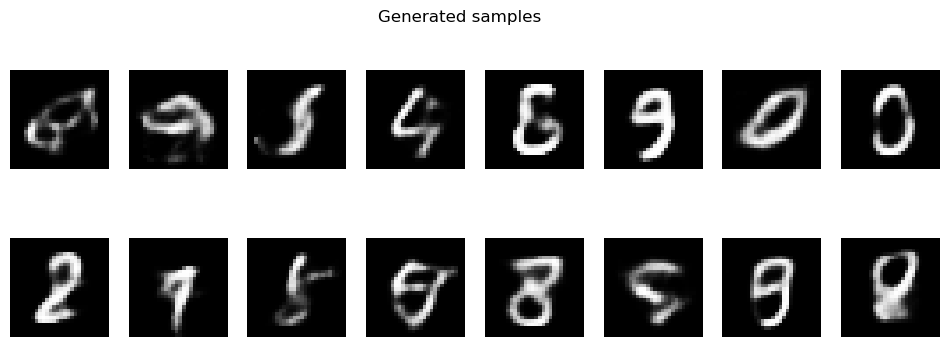

In [58]:
model.eval()

with torch.no_grad():
    z = torch.randn((16,20)).to(device)

    generated = model.decoder(z).cpu()
    generated = generated.view(-1,1,28,28)

# plot generated samples
fig, axes = plt.subplots(2,8,figsize=(12,4))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i][0], cmap='gray')
    ax.axis('off')

plt.suptitle("Generated samples")
plt.show()

# Latent space visualisation

In [59]:
model.eval()
features = []
labels = []
# visualise with PCA
with torch.no_grad():
    for batch_idx, (x, label) in enumerate(train_loader):
        x = x.view(-1, 784).to(device)
        mu, logvar = model.encoder(x)
        features.append(mu)
        labels.append(label)

# cats along the right dimension
features = torch.cat(features, dim=0)
labels = torch.cat(labels, dim=0)

U,S,V=torch.pca_lowrank(features, q=2)

train_2d = torch.matmul(features, V[:,:2])
# pass to cpu for plotting
train_2d = train_2d.to("cpu")
labels = labels.to("cpu")

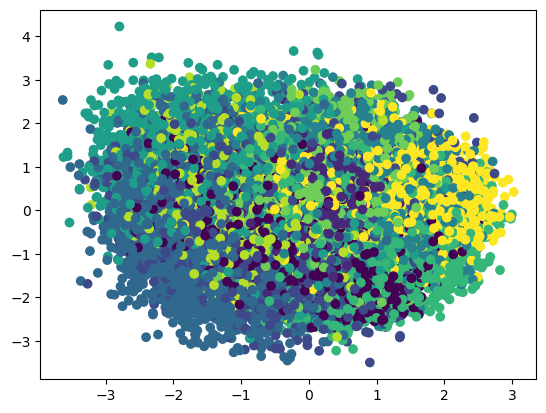

In [60]:
fig, ax = plt.subplots()

ax.scatter(train_2d[:,0], train_2d[:,1],c=labels, cmap='viridis')

plt.show()

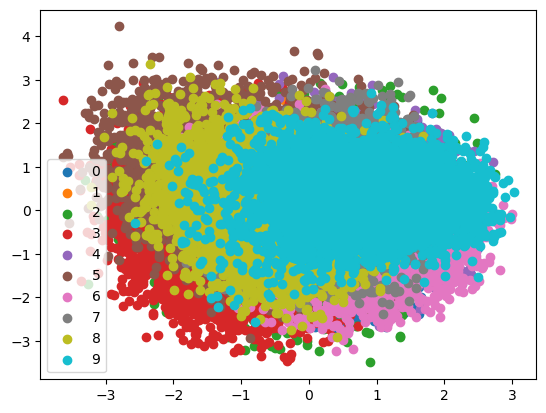

In [61]:
import matplotlib as mpl 

n_lines = 10
cmap = mpl.colormaps['tab10']
colors = [cmap(i) for i in range(10)]
# slightly convoluted way to do the plot
classes = list(range(0,10))

for cls in classes:
    indices = [i for i, c in enumerate(labels) if c == cls]
    subset = torch.utils.data.Subset(train_2d, indices)
    subset = torch.stack([t for t in subset])
    plt.scatter(subset[:,0],subset[:,1], label=cls, color=colors[cls])

#indices = [i for i, c in enumerate(labels) if c == 1]
#display(indices)
#plt.scatter(train_2d[:,0], train_2d[:,1],c=labels, cmap='viridis')
#plt.gca().legend(('1','2','3','4','5','6','7','8'))


plt.legend()
plt.show()


# Sampling from a given class

Idea: figure out the mean parameters for a given class and then use the decoder to generate new numbers basd off this.

In [62]:
# Simple example: class of sixes

indices = [i for i, (e,c) in enumerate(training_data) if c == 6]
sample__set = torch.utils.data.Subset(training_data, indices)

# make a data loader for simpler computation, not sure if necessary (probably not!)
sample_set_loader = DataLoader(dataset=training_data, batch_size=128,shuffle=True)

In [63]:
# Basically reusing code from before
model.eval()

means = []
vars = []

with torch.no_grad():
    for batch_idx, (x, label) in enumerate(sample_set_loader):
        x = x.view(-1, 784).to(device)
        mu, logvar = model.encoder(x)
        
        means.append(mu)
        # to make it sampleable
        vars.append(torch.exp(0.5*logvar))

# flatten the means and variations 
means = torch.cat(means, dim=0)
vars = torch.cat(vars, dim=0)
        

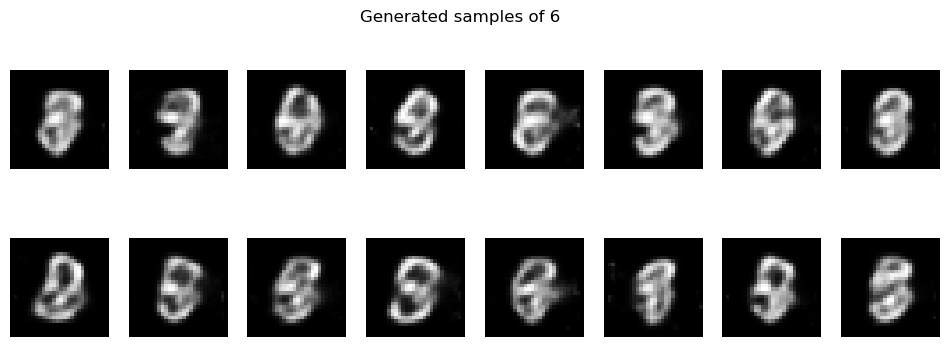

In [64]:
mean = torch.mean(means, dim=0)
var = torch.mean(vars, dim=0)

# sample a few images
with torch.no_grad():
    z = torch.randn((16,20)).to(device)
    # modify to dist using mu+var*z
    class_dist = mean + var*z

    generated = model.decoder(class_dist).cpu()
    generated = generated.view(-1,1,28,28)

# plot generated samples
fig, axes = plt.subplots(2,8,figsize=(12,4))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i][0], cmap='gray')
    ax.axis('off')

plt.suptitle("Generated samples of 6")
plt.show()

Looking at the PCA and the above plots makes me personally feel the model is slightly lacking. This is roughly expected though as it is very simple. What the weakness of the above model is that the distributions (in our model presently) are very overlapping, at least looking at the PCA. For us to really get good results through the method above, we would for instance have to imprvoe the model somehow. The first step migth be to consider the actual model architechture. A convolutional approach might be better as the model might be able to learn the 'structure' of the numbers better compared to just a flat ~800 pixel vector. Of course, an additional benefit is the extensibility of a convolutional approach. Not only could it be used for bigger images, but we could also use it for eventually downscaling bigger images for latent diffusion approaches, which is one of the project aims. 

# More robust model

We will still use MNIST but we will instead use convolution. For convenience, we will resize the images slighty.

In [6]:
from torchvision.transforms import Compose
from torchvision.transforms import ToTensor
from torchvision.transforms import Pad

base_images = datasets.MNIST(
    root="data",
    train=True,
    download="True",
    # resizing images to make them big enough
    transform=Compose([Pad(2),
                       ToTensor()])
    #transform=ToTensor(),
)

base_loader = DataLoader(dataset=base_images, batch_size=128,shuffle=True)

In [70]:
# Define model, encoder decoder seperately

class Encoder(nn.Module):
    # allows for hidden layer etc. experimentation
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        #hidden_dim = 128*(28//8)*(28//8)
        self.f_mu = nn.Linear(2048,latent_dim)
        self.f_logvar = nn.Linear(2048,latent_dim)

        self.encoder_stack = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3,stride=2,padding=1),
            nn.ReLU(),
            nn.Flatten()
        )

    def forward(self,x):
        enc_stack = self.encoder_stack(x)
        mu = self.f_mu(enc_stack)
        f_logvar = self.f_logvar(enc_stack)

        return mu, f_logvar

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super(Decoder, self).__init__()
        #hidden_dim = 128*(28//8)*(28//8)
        #display(hidden_dim)
        pre_flatten_shape = (128, 4, 4)
        # fully connected layer
        self.fc1 = nn.Linear(latent_dim, 2048)
        # define a helper to reshape to allow for tensor operations
        self.reshape = lambda x: x.view(-1, *pre_flatten_shape)

        self.decoder_stack= nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3,stride=2,padding=1, output_padding= 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3,stride=2,padding=1,output_padding= 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3,stride=2,padding=1,output_padding= 1),
            nn.ReLU(),
            nn.Sigmoid()
        )        

    def forward(self,x): 
        x = self.fc1(x)
        x = self.reshape(x)
        
        x = self.decoder_stack(x)
        
        return x


class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    # needed to make the gradients flow
    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5*logvar) # standard deviation
        eps = torch.randn_like(std) # random noise
        return mu+eps*std   # sample

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z= self.reparameterise(mu,logvar)
        reconstructed = self.decoder(z)
        return reconstructed, mu, logvar
    

In [21]:
def loss_function(recon_x, x, mu, logvar):
    # reconstruction loss (binary cross entropy)
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')

    # KL divergence loss
    kl_loss = -0.5*torch.sum(1+logvar-mu.pow(2)-logvar.exp())
    return recon_loss + kl_loss.mean()

Epoch 1, Loss: 711.1055
Epoch 11, Loss: 709.3191
Epoch 21, Loss: 696.7875
Epoch 31, Loss: 695.9289
Epoch 41, Loss: 695.5834
Epoch 51, Loss: 695.3524
Epoch 61, Loss: 695.2197
Epoch 71, Loss: 695.0880
Epoch 81, Loss: 694.7421
Epoch 91, Loss: 694.4905
Epoch 101, Loss: 694.4012
Epoch 111, Loss: 694.3705
Epoch 121, Loss: 694.3577
Epoch 131, Loss: 694.3423
Epoch 141, Loss: 694.3503
Epoch 151, Loss: 694.3266
Epoch 161, Loss: 694.3430
Epoch 171, Loss: 694.3421
Epoch 181, Loss: 694.3299
Epoch 191, Loss: 694.3234


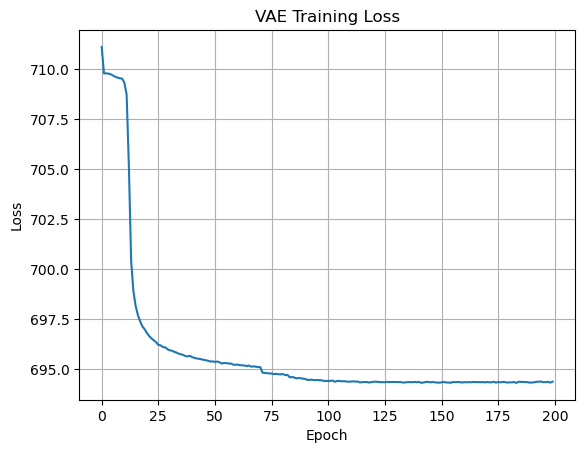

In [73]:
epochs = 200
learning_rate = 1e-3

model = VAE().to(device)
optimizer = torch.optim.AdamW(model.parameters(),lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    mode='min',
    factor=0.5,
    patience=5,
)


train_losses = []

model.train()

for epoch in range(epochs):
    total_loss = 0
    for batch_idx, (x, _) in enumerate(base_loader):
        x = x.to(device)
        optimizer.zero_grad()

        recon_x, mu, logvar = model(x)
        loss = loss_function(recon_x, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    avg_loss = total_loss/len(base_loader.dataset)
    train_losses.append(avg_loss)
    scheduler.step(avg_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

plt.plot(train_losses)
plt.title("VAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()




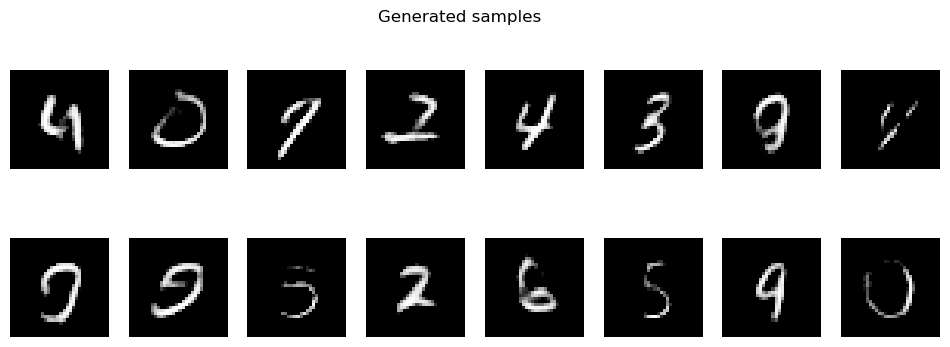

In [77]:
model.eval()

with torch.no_grad():
    z = torch.randn((16,20)).to(device)

    generated = model.decoder(z).cpu()
    generated = generated.view(-1,1,32,32)

# plot generated samples
fig, axes = plt.subplots(2,8,figsize=(12,4))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i][0], cmap='gray')
    ax.axis('off')

plt.suptitle("Generated samples")
plt.show()

In [78]:
model.eval()
features = []
labels = []
# visualise with PCA
with torch.no_grad():
    for batch_idx, (x, label) in enumerate(base_loader):
        x = x.to(device)
        mu, logvar = model.encoder(x)
        features.append(mu)
        labels.append(label)

# cats along the right dimension
features = torch.cat(features, dim=0)
labels = torch.cat(labels, dim=0)

U,S,V=torch.pca_lowrank(features, q=2)

train_2d = torch.matmul(features, V[:,:2])
# pass to cpu for plotting
train_2d = train_2d.to("cpu")
labels = labels.to("cpu")

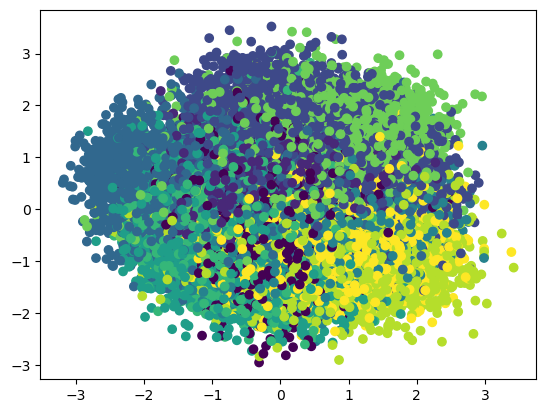

In [79]:
fig, ax = plt.subplots()

ax.scatter(train_2d[:,0], train_2d[:,1],c=labels, cmap='viridis')

plt.show()

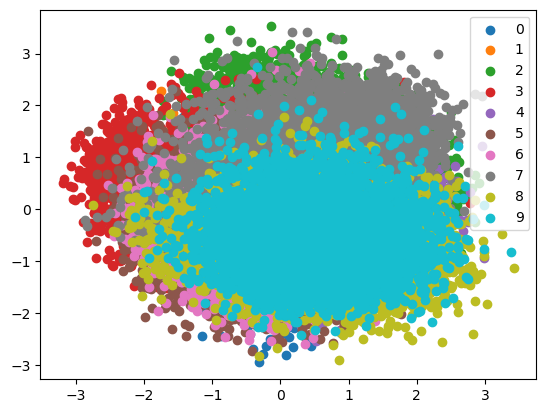

In [80]:
import matplotlib as mpl 

n_lines = 10
cmap = mpl.colormaps['tab10']
colors = [cmap(i) for i in range(10)]
# slightly convoluted way to do the plot
classes = list(range(0,10))

for cls in classes:
    indices = [i for i, c in enumerate(labels) if c == cls]
    subset = torch.utils.data.Subset(train_2d, indices)
    subset = torch.stack([t for t in subset])
    plt.scatter(subset[:,0],subset[:,1], label=cls, color=colors[cls])

#indices = [i for i, c in enumerate(labels) if c == 1]
#display(indices)
#plt.scatter(train_2d[:,0], train_2d[:,1],c=labels, cmap='viridis')
#plt.gca().legend(('1','2','3','4','5','6','7','8'))


plt.legend()
plt.show()

In [81]:
# save the model
torch.save(model.state_dict(), "basic_VAE_wts")

# conditional VAE

In [19]:
# Define model, encoder decoder seperately

class Encoder(nn.Module):
    # allows for hidden layer etc. experimentation
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        #hidden_dim = 128*(28//8)*(28//8)
        
        # some code for label embedding
        self.embedding = nn.Embedding(10, 32)
        # account for the additional layers.
        self.f_mu = nn.Linear(2048+32,latent_dim)
        self.f_logvar = nn.Linear(2048+32,latent_dim)

        

        self.encoder_stack = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3,stride=2,padding=1),
            nn.ReLU(),
            nn.Flatten()
        )
    """
    Inputs: 
        x: image
        c: label of image
    """
    def forward(self,x, c):
        x = self.encoder_stack(x)
        c = self.embedding(c)
        
        x = torch.cat([x, c], dim=1)

        mu = self.f_mu(x)
        f_logvar = self.f_logvar(x)

        return mu, f_logvar

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super(Decoder, self).__init__()
        #hidden_dim = 128*(28//8)*(28//8)
        #display(hidden_dim)
        pre_flatten_shape = (128, 4, 4)
        self.embedding = nn.Embedding(10, 32)
        # fully connected layer
        self.decoder_input = nn.Linear(latent_dim+32, 2048)
        # define a helper to reshape to allow for tensor operations
        self.reshape = lambda x: x.view(-1, *pre_flatten_shape)

        self.decoder_stack= nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3,stride=2,padding=1, output_padding= 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3,stride=2,padding=1,output_padding= 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3,stride=2,padding=1,output_padding= 1),
            nn.ReLU(),
            nn.Sigmoid()
        )        
    """
    The forward function.
    Inputs:
    z: 'sample' from distribution
    c: label"""
    def forward(self,z,c): 
        c= self.embedding(c)

        z = torch.cat([z,c], dim=1)
        z = self.decoder_input(z)
        z = self.reshape(z)
        z = self.decoder_stack(z)
        return z


class CVAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(CVAE, self).__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    # needed to make the gradients flow
    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5*logvar) # standard deviation
        eps = torch.randn_like(std) # random noise
        return mu+eps*std   # sample

    def forward(self, x,c):
        mu, logvar = self.encoder(x,c)
        z= self.reparameterise(mu,logvar)
        reconstructed = self.decoder(z,c)
        return reconstructed, mu, logvar
    

# Train the model

Epoch 1, Loss: 707.7028
Epoch 11, Loss: 693.2842
Epoch 21, Loss: 692.3913
Epoch 31, Loss: 691.9262
Epoch 41, Loss: 691.6136
Epoch 51, Loss: 691.4399
Epoch 61, Loss: 691.2660
Epoch 71, Loss: 690.8363
Epoch 81, Loss: 690.5831
Epoch 91, Loss: 690.4052
Epoch 101, Loss: 690.3874
Epoch 111, Loss: 690.3608
Epoch 121, Loss: 690.3608
Epoch 131, Loss: 690.3626
Epoch 141, Loss: 690.3433
Epoch 151, Loss: 690.3347
Epoch 161, Loss: 690.3565
Epoch 171, Loss: 690.3341
Epoch 181, Loss: 690.3496
Epoch 191, Loss: 690.3443


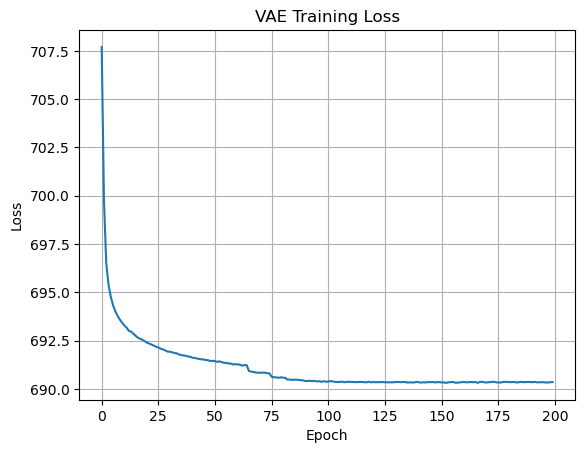

In [23]:
epochs = 200
learning_rate = 1e-3

model = CVAE().to(device)
optimizer = torch.optim.AdamW(model.parameters(),lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    mode='min',
    factor=0.5,
    patience=5,
)


train_losses = []

model.train()

for epoch in range(epochs):
    total_loss = 0
    for batch_idx, (x, c) in enumerate(base_loader):
        x = x.to(device)
        c = c.to(device)
        optimizer.zero_grad()

        recon_x, mu, logvar = model(x,c)
        loss = loss_function(recon_x, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    avg_loss = total_loss/len(base_loader.dataset)
    train_losses.append(avg_loss)
    scheduler.step(avg_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

plt.plot(train_losses)
plt.title("VAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()




In [25]:
# Save model weigths, just in case
torch.save(model.state_dict(), "basic_CVAE_wts")

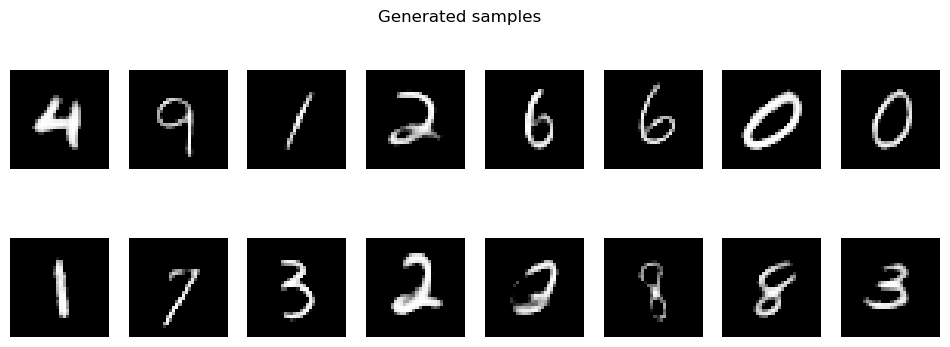

In [ ]:
model.eval()

with torch.no_grad():
    # draw some Cs randomly
    c = torch.randint(10, (16,)).to(device)

    z = torch.randn((16,20)).to(device)
    
    generated = model.decoder(z,c).cpu()
    generated = generated.view(-1,1,32,32)

# return the draws to device so that we can use them to visualsie samples
c = c.cpu
# plot generated samples
fig, axes = plt.subplots(2,8,figsize=(12,4))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i][0], cmap='gray')
    ax.axis('off')
    ax.set_title(f"draw from {c[i]}")


plt.suptitle("Generated samples")
plt.show()